# Step 3 — Business Questions Analysis
**Data Warehouse:** `sakila_dw`  
**Each question includes:** Result Table + Chart  

> Run Step 1 (structure SQL) and Step 2 (ETL notebook) before this file.

## 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sqlalchemy import create_engine

HOST     = '127.0.0.1'
PORT     = 3306
USER     = 'root'
PASSWORD = 'ramasabitbel'   # ← change to your password

dw = create_engine(
    f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/sakila_dw',
    echo=False
)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})
C = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0',
     '#00BCD4','#FF5722','#607D8B','#8BC34A','#FFC107',
     '#3F51B5','#009688','#795548','#F44336','#CDDC39']

print('Connected to sakila_dw ✓')


Connected to sakila_dw ✓


---
## Q1 — Which films are rented most frequently?

Q1 — Top 10 Most Rented Films
              title  category  total_rentals
 BUCKET BROTHERHOOD    Travel             34
   ROCKETEER MOTHER   Foreign             33
     GRIT CLOCKWORK     Games             32
RIDGEMONT SUBMARINE       New             32
     FORWARD TEMPLE     Games             32
     JUGGLER HARDLY Animation             32
      SCALAWAG DUCK     Music             32
       NETWORK PEAK    Family             31
       ROBBERS JOON  Children             31
    RUSH GOODFELLAS    Family             31


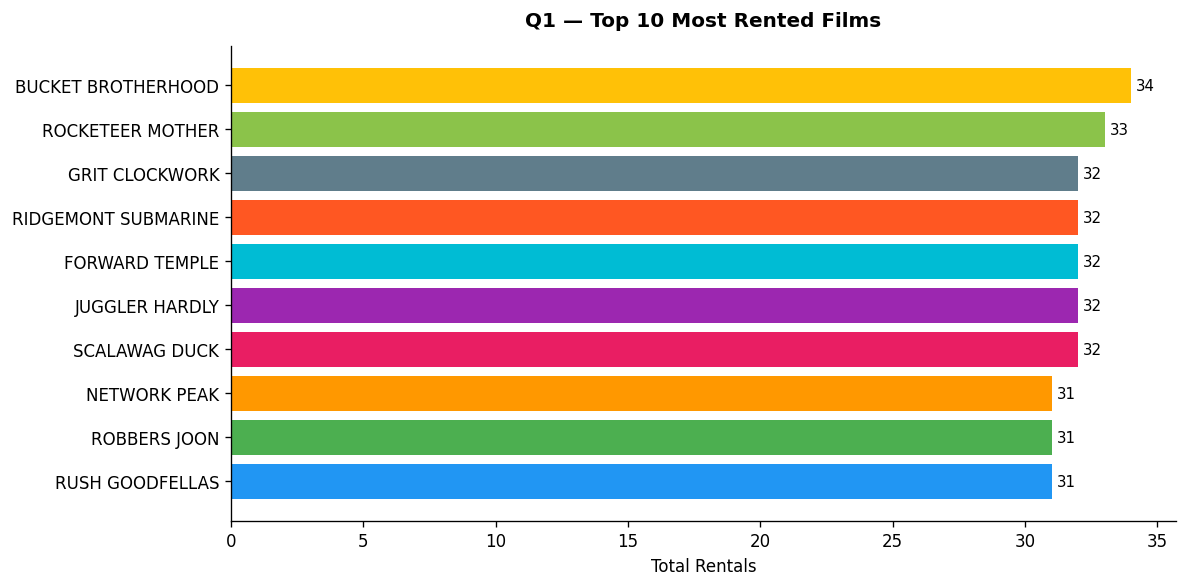

In [2]:
q1 = pd.read_sql('''
    SELECT f.title,
           c.name                   AS category,
           COUNT(r.rental_key)      AS total_rentals
    FROM   fact_rental  r
    JOIN   dim_film     f ON r.film_key     = f.film_key
    JOIN   dim_category c ON r.category_key = c.category_key
    GROUP  BY f.film_key, f.title, c.name
    ORDER  BY total_rentals DESC
    LIMIT  10
''', dw)

print("Q1 — Top 10 Most Rented Films")
print(q1.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(q1['title'][::-1], q1['total_rentals'][::-1], color=C[:10])
ax.set_xlabel('Total Rentals')
ax.set_title('Q1 — Top 10 Most Rented Films', fontweight='bold', pad=12)
for b in bars:
    ax.text(b.get_width()+.2, b.get_y()+b.get_height()/2,
            str(int(b.get_width())), va='center', fontsize=9)
plt.tight_layout(); plt.show()


---
## Q2 — Which films generate the highest revenue?

Q2 — Top 10 Films by Revenue
            title    category  total_revenue
 TELEGRAPH VOYAGE       Music         231.73
        WIFE TURN Documentary         223.69
        ZORRO ARK      Comedy         214.69
GOODFELLAS SALUTE      Sci-Fi         209.69
   SATURDAY LAMBS      Sports         204.72
      TITANS JERK      Sci-Fi         201.71
     TORQUE BOUND       Drama         198.72
      HARRY IDAHO       Drama         195.70
   INNOCENT USUAL     Foreign         191.74
    HUSTLER PARTY      Comedy         190.78


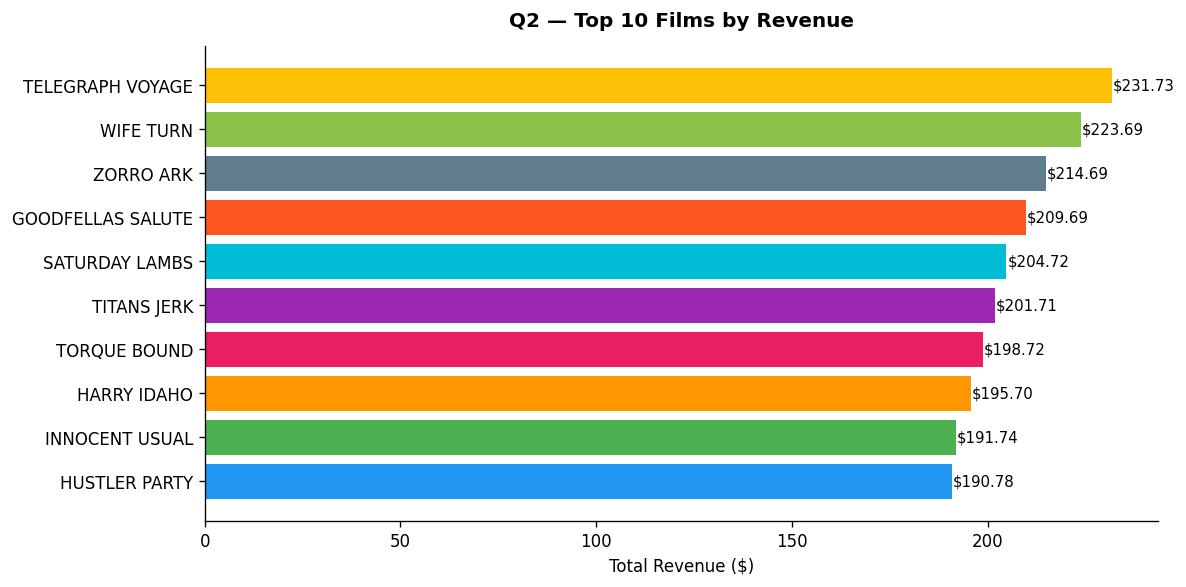

In [3]:
q2 = pd.read_sql('''
    SELECT f.title,
           c.name                        AS category,
           ROUND(SUM(p.amount_paid), 2)  AS total_revenue
    FROM   fact_payment p
    JOIN   fact_rental  r ON p.rental_key   = r.rental_key
    JOIN   dim_film     f ON r.film_key     = f.film_key
    JOIN   dim_category c ON r.category_key = c.category_key
    GROUP  BY f.film_key, f.title, c.name
    ORDER  BY total_revenue DESC
    LIMIT  10
''', dw)

print("Q2 — Top 10 Films by Revenue")
print(q2.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(q2['title'][::-1], q2['total_revenue'][::-1], color=C[:10])
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Q2 — Top 10 Films by Revenue', fontweight='bold', pad=12)
for b in bars:
    ax.text(b.get_width()+.2, b.get_y()+b.get_height()/2,
            f'${b.get_width():.2f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


---
## Q3 — Which film categories are most popular?

Q3 — Categories by Popularity
   category  total_rentals
     Sports           1179
  Animation           1166
     Action           1112
     Sci-Fi           1101
     Family           1096
      Drama           1060
Documentary           1050
    Foreign           1033
      Games            969
   Children            945
     Comedy            941
        New            940
   Classics            939
     Horror            846
     Travel            837
      Music            830


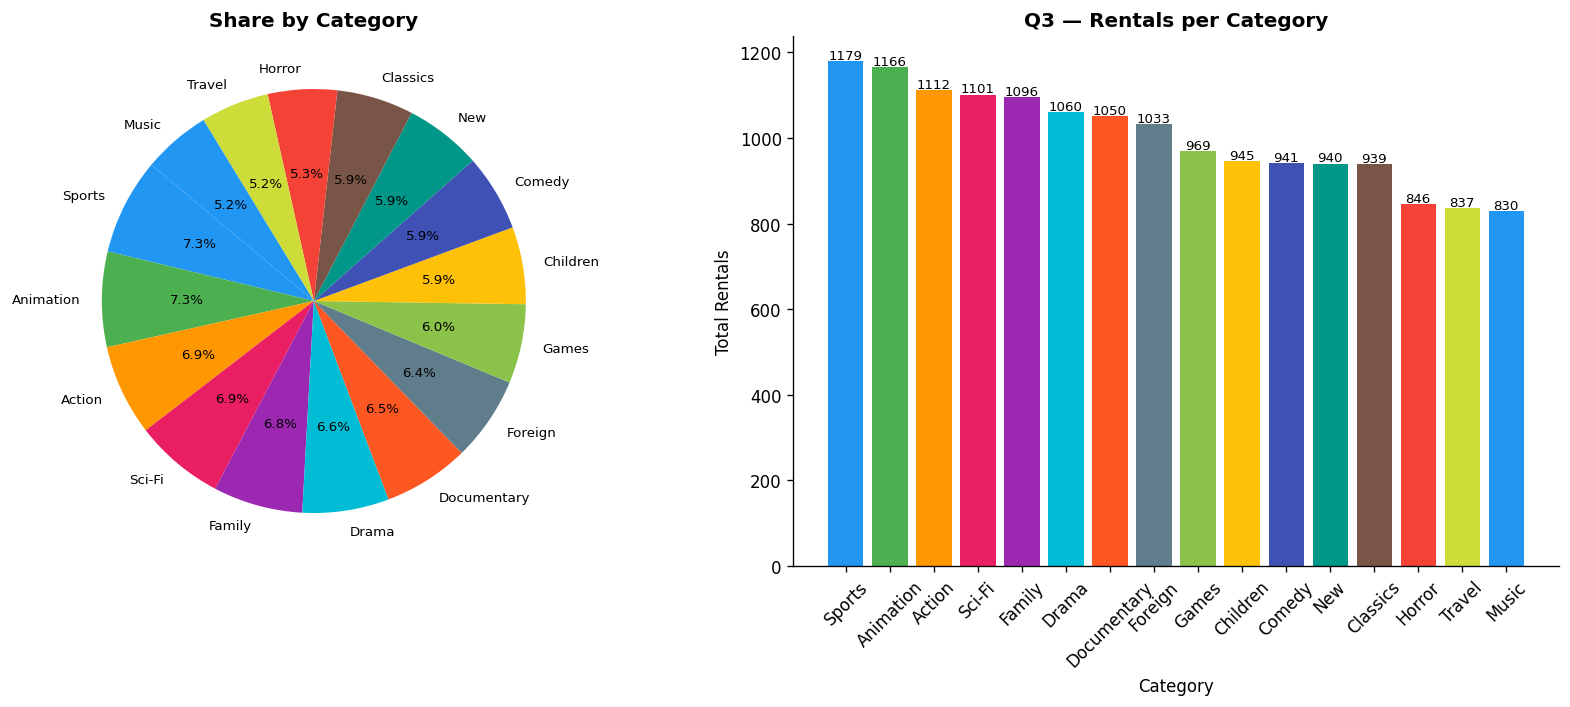

In [4]:
q3 = pd.read_sql('''
    SELECT c.name                   AS category,
           COUNT(r.rental_key)      AS total_rentals
    FROM   fact_rental  r
    JOIN   dim_category c ON r.category_key = c.category_key
    GROUP  BY c.category_key, c.name
    ORDER  BY total_rentals DESC
''', dw)

print("Q3 — Categories by Popularity")
print(q3.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
ax1.pie(q3['total_rentals'], labels=q3['category'],
        colors=C[:len(q3)], autopct='%1.1f%%',
        startangle=140, textprops={'fontsize':8})
ax1.set_title('Share by Category', fontweight='bold')
bars = ax2.bar(q3['category'], q3['total_rentals'], color=C[:len(q3)])
ax2.set_xlabel('Category'); ax2.set_ylabel('Total Rentals')
ax2.set_title('Q3 — Rentals per Category', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+5,
             str(int(b.get_height())), ha='center', fontsize=8)
plt.tight_layout(); plt.show()


---
## Q4 — Which stores generate the highest number of rentals?

Q4 — Stores by Number of Rentals
 store_id             location manager_name  total_rentals
        2 Woodridge, Australia Jon Stephens           8121
        1   Lethbridge, Canada Mike Hillyer           7923


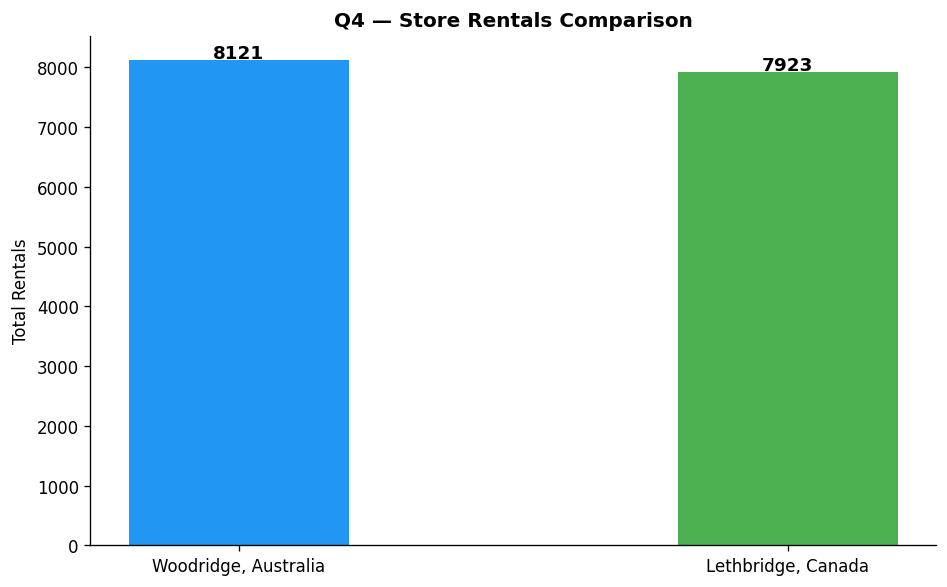

In [5]:
q4 = pd.read_sql('''
    SELECT s.store_id,
           CONCAT(s.city,', ',s.country) AS location,
           s.manager_name,
           COUNT(r.rental_key)           AS total_rentals
    FROM   fact_rental r
    JOIN   dim_store   s ON r.store_key = s.store_key
    GROUP  BY s.store_key, s.store_id, s.city, s.country, s.manager_name
    ORDER  BY total_rentals DESC
''', dw)

print("Q4 — Stores by Number of Rentals")
print(q4.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(q4['location'], q4['total_rentals'], color=C[:len(q4)], width=0.4)
ax.set_ylabel('Total Rentals')
ax.set_title('Q4 — Store Rentals Comparison', fontweight='bold')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30,
            str(int(b.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Q5 — Which stores generate the highest revenue?

Q5 — Stores by Revenue
 store_id             location manager_name  total_revenue
        2 Woodridge, Australia Jon Stephens       33726.77
        1   Lethbridge, Canada Mike Hillyer       33679.79


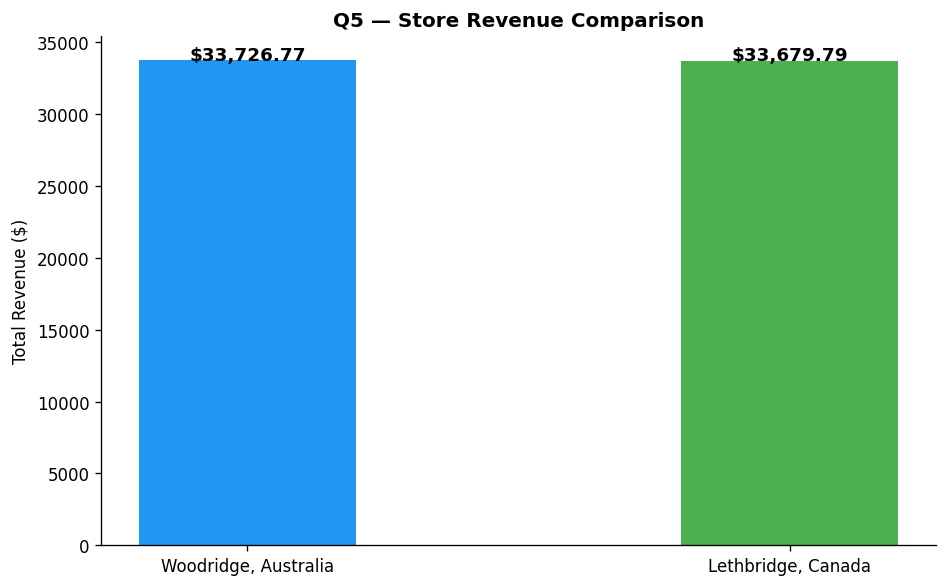

In [6]:
q5 = pd.read_sql('''
    SELECT s.store_id,
           CONCAT(s.city,', ',s.country) AS location,
           s.manager_name,
           ROUND(SUM(p.amount_paid),2)   AS total_revenue
    FROM   fact_payment p
    JOIN   fact_rental  r ON p.rental_key = r.rental_key
    JOIN   dim_store    s ON r.store_key  = s.store_key
    GROUP  BY s.store_key, s.store_id, s.city, s.country, s.manager_name
    ORDER  BY total_revenue DESC
''', dw)

print("Q5 — Stores by Revenue")
print(q5.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(q5['location'], q5['total_revenue'], color=['#2196F3','#4CAF50'], width=0.4)
ax.set_ylabel('Total Revenue ($)')
ax.set_title('Q5 — Store Revenue Comparison', fontweight='bold')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50,
            f'${b.get_height():,.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Q6 — Which customers rent the most films?

Q6 — Top 10 Customers by Rentals
 customer_name                city       country  total_rentals
  ELEANOR HUNT         Saint-Denis       Réunion             46
     KARL SEAL          Cape Coral United States             45
    CLARA SHAW          Molodetšno       Belarus             42
   MARCIA DEAN               Tanza   Philippines             42
 TAMMY SANDERS            Changhwa        Taiwan             41
    SUE PETERS           Changzhou         China             40
   WESLEY BULL    Ourense (Orense)         Spain             40
 MARION SNYDER Santa Brbara dOeste        Brazil             39
RHONDA KENNEDY           Apeldoorn   Netherlands             39
      TIM CARY             Bijapur         India             39


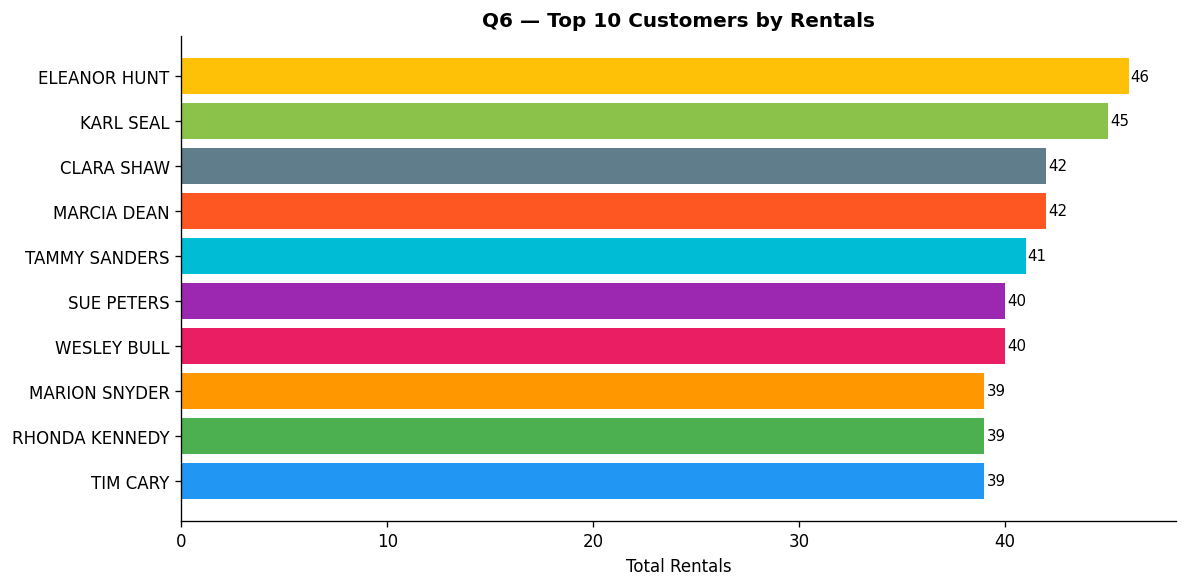

In [7]:
q6 = pd.read_sql('''
    SELECT CONCAT(c.first_name,' ',c.last_name) AS customer_name,
           c.city, c.country,
           COUNT(r.rental_key)                  AS total_rentals
    FROM   fact_rental  r
    JOIN   dim_customer c ON r.customer_key = c.customer_key
    WHERE  c.is_current = 1
    GROUP  BY c.customer_key, c.first_name, c.last_name, c.city, c.country
    ORDER  BY total_rentals DESC
    LIMIT  10
''', dw)

print("Q6 — Top 10 Customers by Rentals")
print(q6.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(q6['customer_name'][::-1], q6['total_rentals'][::-1], color=C[:10])
ax.set_xlabel('Total Rentals')
ax.set_title('Q6 — Top 10 Customers by Rentals', fontweight='bold')
for b in bars:
    ax.text(b.get_width()+.1, b.get_y()+b.get_height()/2,
            str(int(b.get_width())), va='center', fontsize=9)
plt.tight_layout(); plt.show()


---
## Q7 — Which customers generate the highest revenue?

Q7 — Top 10 Customers by Revenue
 customer_name                city       country  total_rentals  total_spent
     KARL SEAL          Cape Coral United States             45       221.55
  ELEANOR HUNT         Saint-Denis       Réunion             46       216.54
    CLARA SHAW          Molodetšno       Belarus             42       195.58
RHONDA KENNEDY           Apeldoorn   Netherlands             39       194.61
 MARION SNYDER Santa Brbara dOeste        Brazil             39       194.61
 TOMMY COLLAZO             Qomsheh          Iran             38       186.62
   WESLEY BULL    Ourense (Orense)         Spain             40       177.60
      TIM CARY             Bijapur         India             39       175.61
   MARCIA DEAN               Tanza   Philippines             42       175.58
   ANA BRADLEY             Memphis United States             34       174.66


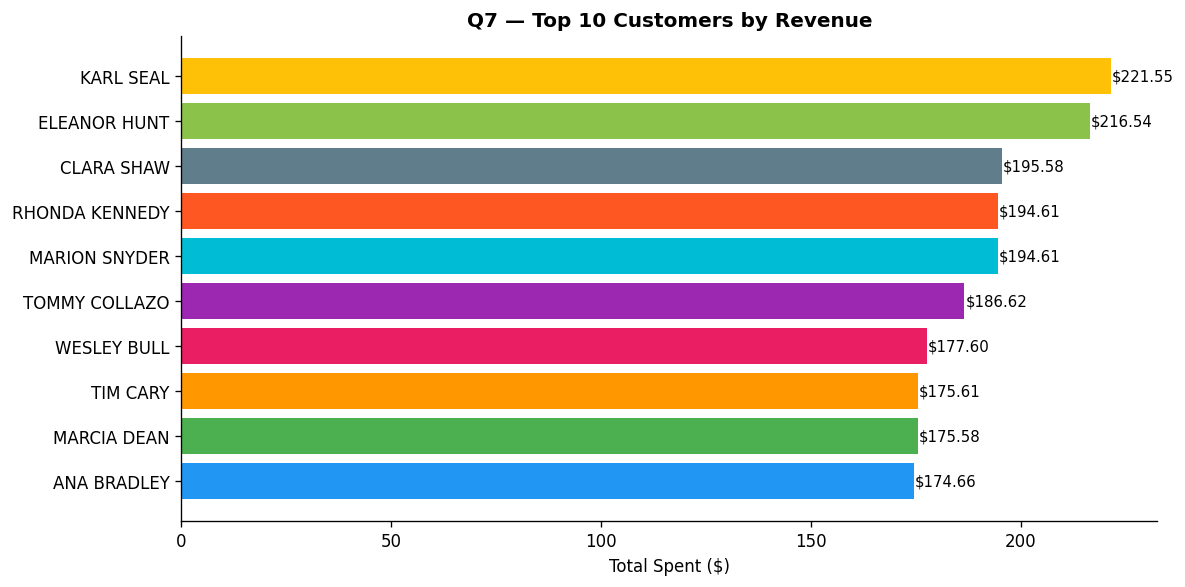

In [8]:
q7 = pd.read_sql('''
    SELECT CONCAT(c.first_name,' ',c.last_name) AS customer_name,
           c.city, c.country,
           COUNT(r.rental_key)                  AS total_rentals,
           ROUND(SUM(p.amount_paid),2)           AS total_spent
    FROM   fact_rental  r
    JOIN   dim_customer c ON r.customer_key = c.customer_key
    JOIN   fact_payment p ON r.rental_key   = p.rental_key
    WHERE  c.is_current = 1
    GROUP  BY c.customer_key, c.first_name, c.last_name, c.city, c.country
    ORDER  BY total_spent DESC
    LIMIT  10
''', dw)

print("Q7 — Top 10 Customers by Revenue")
print(q7.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(q7['customer_name'][::-1], q7['total_spent'][::-1], color=C[:10])
ax.set_xlabel('Total Spent ($)')
ax.set_title('Q7 — Top 10 Customers by Revenue', fontweight='bold')
for b in bars:
    ax.text(b.get_width()+.2, b.get_y()+b.get_height()/2,
            f'${b.get_width():.2f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


---
## Q8 — How does rental activity change over time?

Q8 — Rental Activity Over Time
 year  month_number month_name  total_rentals
 2005             5        May           1156
 2005             6       June           2311
 2005             7       July           6709
 2005             8     August           5686
 2006             2   February            182


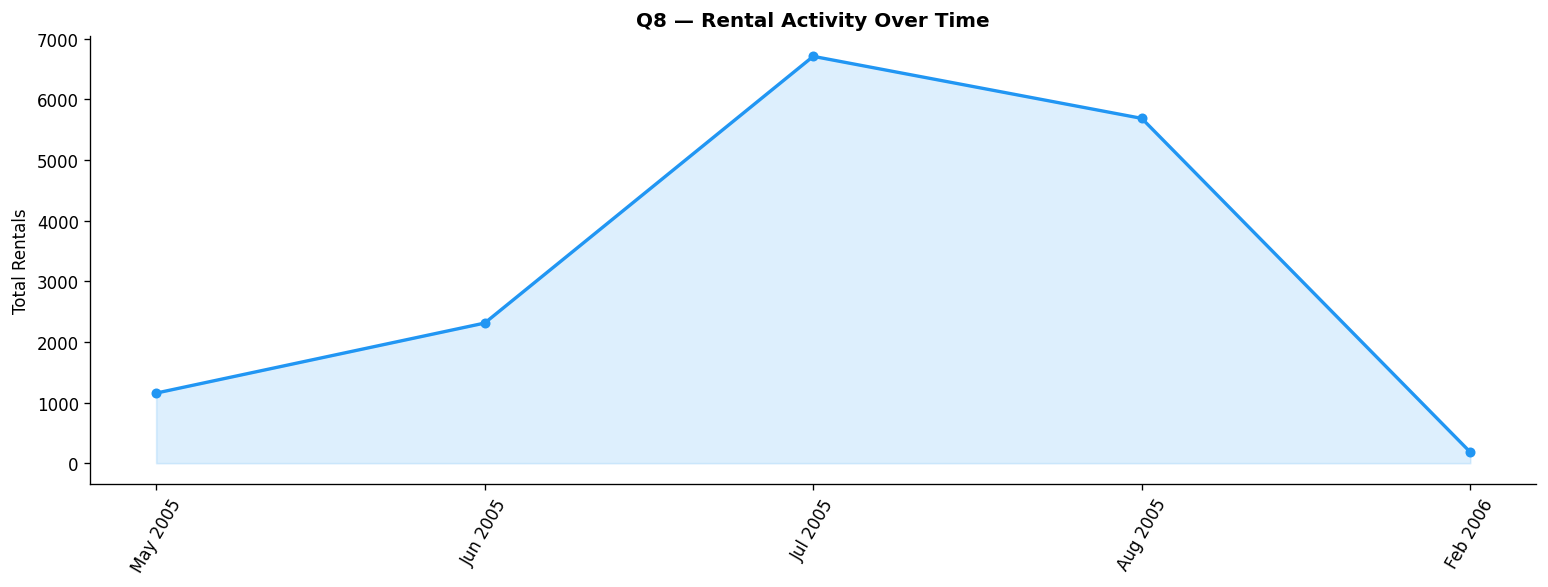

In [9]:
q8 = pd.read_sql('''
    SELECT d.year, d.month_number, d.month_name,
           COUNT(r.rental_key) AS total_rentals
    FROM   fact_rental r
    JOIN   dim_date    d ON r.rental_date_key = d.date_key
    GROUP  BY d.year, d.month_number, d.month_name
    ORDER  BY d.year, d.month_number
''', dw)

print("Q8 — Rental Activity Over Time")
print(q8.to_string(index=False))

q8['period'] = q8['month_name'].str[:3]+' '+q8['year'].astype(str)
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(q8['period'], q8['total_rentals'], 'o-',
        color='#2196F3', linewidth=2, markersize=5)
ax.fill_between(range(len(q8)), q8['total_rentals'], alpha=0.15, color='#2196F3')
ax.set_ylabel('Total Rentals')
ax.set_title('Q8 — Rental Activity Over Time', fontweight='bold')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.show()


---
## Q9 — How does revenue change by month, quarter, and year?

Monthly Revenue:
 year  month_number month_name  revenue
 2005             5        May  4823.44
 2005             6       June  9629.89
 2005             7       July 28368.91
 2005             8     August 24070.14
 2006             2   February   514.18

Quarterly Revenue:
 year  quarter  revenue
 2005        2 14453.33
 2005        3 52439.05
 2006        1   514.18

Yearly Revenue:
 year  revenue
 2005 66892.38
 2006   514.18


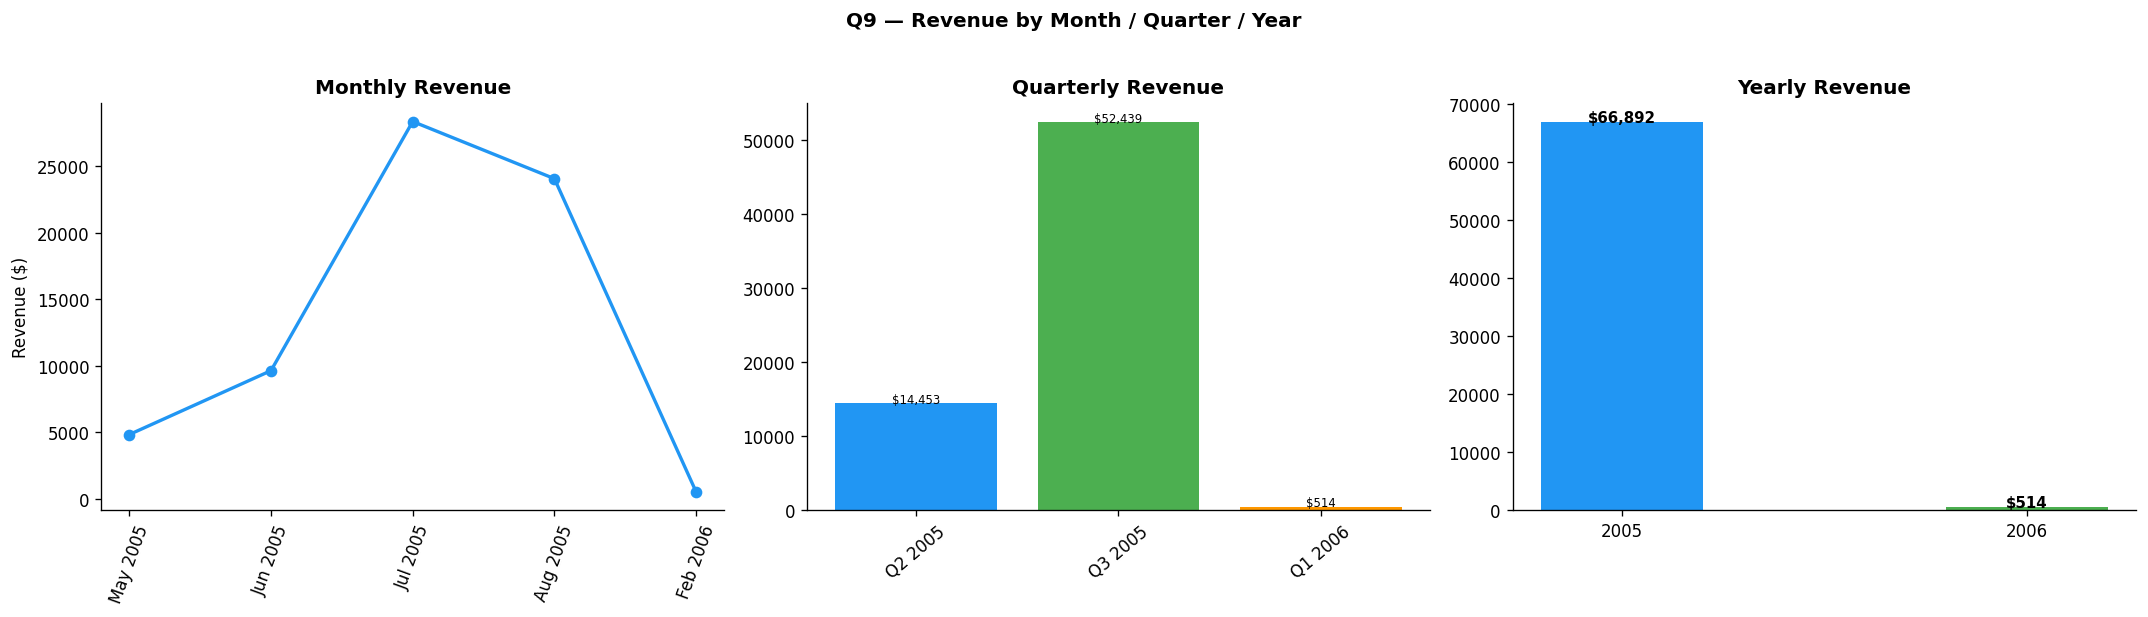

In [10]:
# monthly
q9m = pd.read_sql('''
    SELECT d.year, d.month_number, d.month_name,
           ROUND(SUM(p.amount_paid),2) AS revenue
    FROM   fact_payment p
    JOIN   dim_date     d ON p.payment_date_key = d.date_key
    GROUP  BY d.year, d.month_number, d.month_name
    ORDER  BY d.year, d.month_number
''', dw)

# quarterly
q9q = pd.read_sql('''
    SELECT d.year, d.quarter,
           ROUND(SUM(p.amount_paid),2) AS revenue
    FROM   fact_payment p
    JOIN   dim_date     d ON p.payment_date_key = d.date_key
    GROUP  BY d.year, d.quarter
    ORDER  BY d.year, d.quarter
''', dw)

# yearly
q9y = pd.read_sql('''
    SELECT d.year,
           ROUND(SUM(p.amount_paid),2) AS revenue
    FROM   fact_payment p
    JOIN   dim_date     d ON p.payment_date_key = d.date_key
    GROUP  BY d.year
    ORDER  BY d.year
''', dw)

print("Monthly Revenue:"); print(q9m.to_string(index=False))
print("\nQuarterly Revenue:"); print(q9q.to_string(index=False))
print("\nYearly Revenue:"); print(q9y.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# monthly line
q9m['period'] = q9m['month_name'].str[:3]+' '+q9m['year'].astype(str)
axes[0].plot(q9m['period'], q9m['revenue'], 'o-', color='#2196F3', linewidth=2)
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].tick_params(axis='x', rotation=70)
axes[0].set_ylabel('Revenue ($)')

# quarterly bar
q9q['period'] = 'Q'+q9q['quarter'].astype(str)+' '+q9q['year'].astype(str)
axes[1].bar(q9q['period'], q9q['revenue'], color=C[:len(q9q)])
axes[1].set_title('Quarterly Revenue', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
for b in axes[1].patches:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                 f'${b.get_height():,.0f}', ha='center', fontsize=7)

# yearly bar
axes[2].bar(q9y['year'].astype(str), q9y['revenue'], color=C[:len(q9y)], width=0.4)
axes[2].set_title('Yearly Revenue', fontweight='bold')
for b in axes[2].patches:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                 f'${b.get_height():,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Q9 — Revenue by Month / Quarter / Year', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
## Q10 — Which staff members process the most rentals and payments?

Q10 — Staff Performance
  staff_name  store_id  rentals_processed  total_collected
Jon Stephens         2               8004         33881.94
Mike Hillyer         1               8040         33524.62


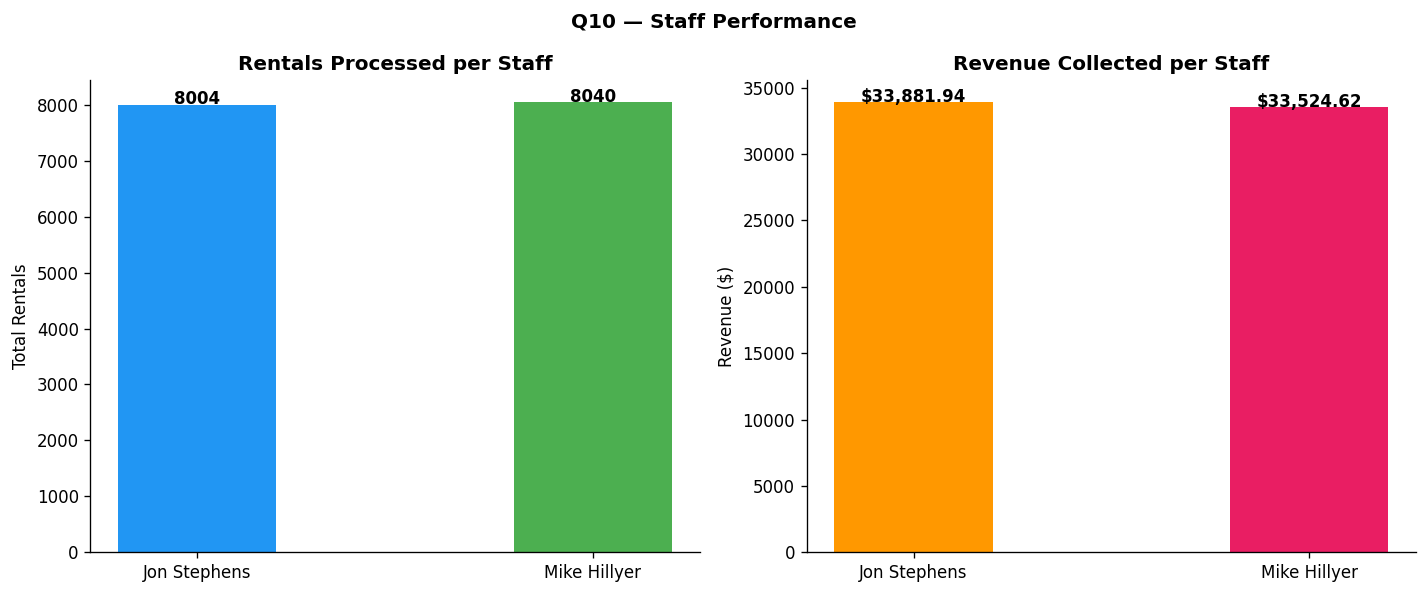

In [11]:
q10 = pd.read_sql('''
    SELECT st.full_name                   AS staff_name,
           st.store_id,
           COUNT(r.rental_key)            AS rentals_processed,
           ROUND(SUM(p.amount_paid),2)    AS total_collected
    FROM   fact_rental  r
    JOIN   dim_staff    st ON r.staff_key  = st.staff_key
    JOIN   fact_payment p  ON r.rental_key = p.rental_key
    GROUP  BY st.staff_key, st.full_name, st.store_id
    ORDER  BY total_collected DESC
''', dw)

print("Q10 — Staff Performance")
print(q10.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.bar(q10['staff_name'], q10['rentals_processed'], color=['#2196F3','#4CAF50'], width=0.4)
ax1.set_title('Rentals Processed per Staff', fontweight='bold')
ax1.set_ylabel('Total Rentals')
for b in ax1.patches:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+10,
             str(int(b.get_height())), ha='center', fontweight='bold')

ax2.bar(q10['staff_name'], q10['total_collected'], color=['#FF9800','#E91E63'], width=0.4)
ax2.set_title('Revenue Collected per Staff', fontweight='bold')
ax2.set_ylabel('Revenue ($)')
for b in ax2.patches:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+10,
             f'${b.get_height():,.2f}', ha='center', fontweight='bold')

plt.suptitle('Q10 — Staff Performance', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Q11 — Which cities or countries generate the highest customer activity?

Q11 — Top 10 Countries
           country  unique_customers  total_rentals  total_revenue
             India                60           1572        6628.28
             China                53           1426        5798.74
     United States                36            968        4110.32
             Japan                31            825        3470.75
            Mexico                30            796        3307.04
            Brazil                28            748        3200.52
Russian Federation                28            713        3045.87
       Philippines                20            568        2381.32
            Turkey                15            388        1662.12
         Indonesia                14            367        1510.33

Q11 — Top 10 Cities
            city        country  total_rentals  total_revenue
          Aurora  United States             50         198.50
          London United Kingdom             48         180.52
     Saint-Denis        Réunion  

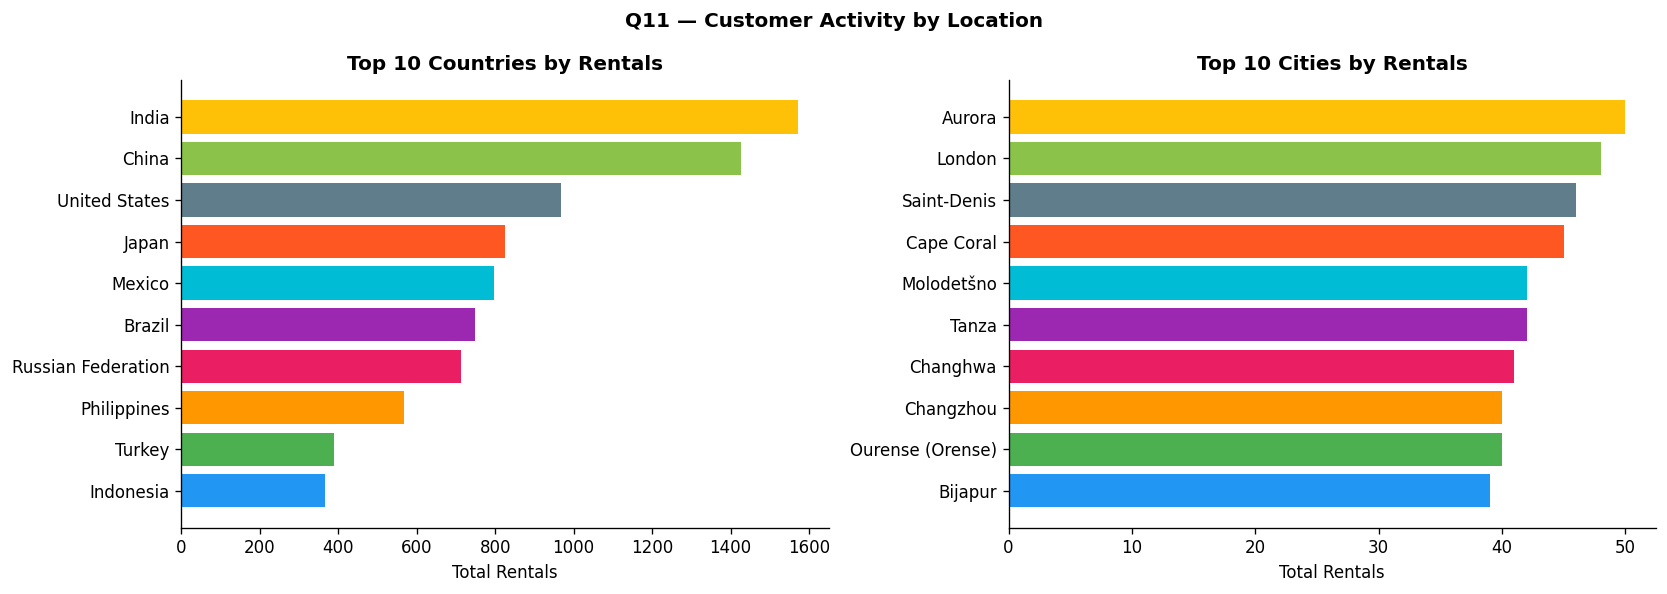

In [12]:
# by country
q11c = pd.read_sql('''
    SELECT c.country,
           COUNT(DISTINCT r.customer_key) AS unique_customers,
           COUNT(r.rental_key)            AS total_rentals,
           ROUND(SUM(p.amount_paid),2)    AS total_revenue
    FROM   fact_rental  r
    JOIN   dim_customer c ON r.customer_key = c.customer_key
    JOIN   fact_payment p ON r.rental_key   = p.rental_key
    WHERE  c.is_current = 1
    GROUP  BY c.country
    ORDER  BY total_rentals DESC
    LIMIT  10
''', dw)

# by city
q11ci = pd.read_sql('''
    SELECT c.city, c.country,
           COUNT(r.rental_key)         AS total_rentals,
           ROUND(SUM(p.amount_paid),2) AS total_revenue
    FROM   fact_rental  r
    JOIN   dim_customer c ON r.customer_key = c.customer_key
    JOIN   fact_payment p ON r.rental_key   = p.rental_key
    WHERE  c.is_current = 1
    GROUP  BY c.city, c.country
    ORDER  BY total_rentals DESC
    LIMIT  10
''', dw)

print("Q11 — Top 10 Countries"); print(q11c.to_string(index=False))
print("\nQ11 — Top 10 Cities");   print(q11ci.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.barh(q11c['country'][::-1], q11c['total_rentals'][::-1], color=C[:10])
ax1.set_xlabel('Total Rentals')
ax1.set_title('Top 10 Countries by Rentals', fontweight='bold')

ax2.barh(q11ci['city'][::-1], q11ci['total_rentals'][::-1], color=C[:10])
ax2.set_xlabel('Total Rentals')
ax2.set_title('Top 10 Cities by Rentals', fontweight='bold')

plt.suptitle('Q11 — Customer Activity by Location', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Q12 — What is the average rental duration for different films or categories?

Q12 — Avg Rental Duration by Category
   category  avg_actual_days  avg_allowed_days
     Sports             4.70              4.74
      Games             4.69              5.01
     Comedy             4.66              4.80
     Sci-Fi             4.58              4.78
      Music             4.57              5.26
     Horror             4.56              4.93
Documentary             4.55              4.65
     Family             4.54              5.16
        New             4.53              4.50
     Action             4.52              4.94
    Foreign             4.51              5.11
   Children             4.44              5.00
   Classics             4.44              4.94
  Animation             4.38              4.81
      Drama             4.37              5.06
     Travel             4.35              5.47

Q12 — Top 10 Films by Avg Rental Duration
            title  avg_days
   IMPACT ALADDIN      6.89
      FLIGHT LIES      6.83
      AFRICAN EGG      6.73
   HARDL

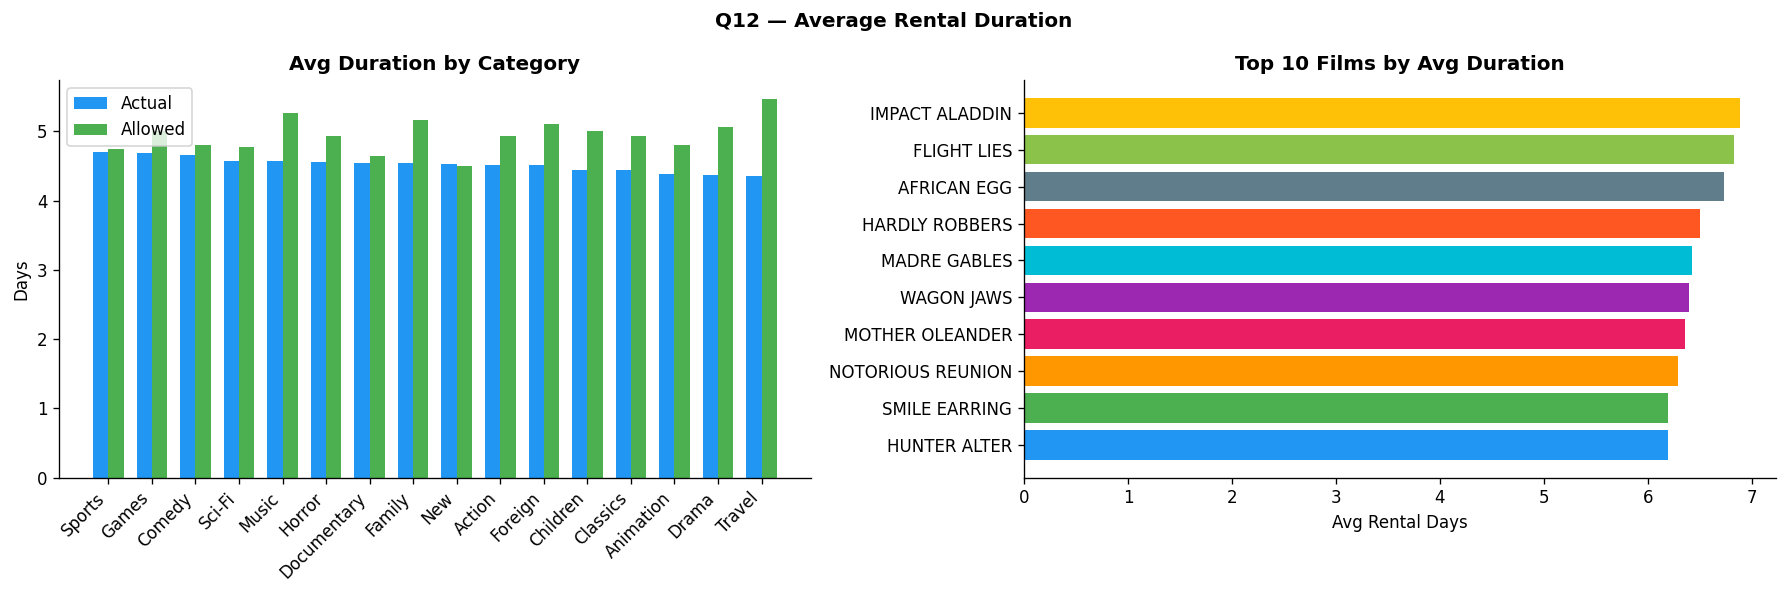

In [13]:
# by category
q12c = pd.read_sql('''
    SELECT c.name                                   AS category,
           ROUND(AVG(r.rental_duration_days),  2)   AS avg_actual_days,
           ROUND(AVG(r.allowed_duration_days), 2)   AS avg_allowed_days
    FROM   fact_rental  r
    JOIN   dim_category c ON r.category_key = c.category_key
    WHERE  r.is_returned = 1
    GROUP  BY c.category_key, c.name
    ORDER  BY avg_actual_days DESC
''', dw)

# by film top 10
q12f = pd.read_sql('''
    SELECT f.title,
           ROUND(AVG(r.rental_duration_days), 2) AS avg_days
    FROM   fact_rental r
    JOIN   dim_film    f ON r.film_key = f.film_key
    WHERE  r.is_returned = 1
    GROUP  BY f.film_key, f.title
    ORDER  BY avg_days DESC
    LIMIT  10
''', dw)

print("Q12 — Avg Rental Duration by Category"); print(q12c.to_string(index=False))
print("\nQ12 — Top 10 Films by Avg Rental Duration"); print(q12f.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
x = range(len(q12c))
w = 0.35
ax1.bar([i-w/2 for i in x], q12c['avg_actual_days'],  w, label='Actual',  color='#2196F3')
ax1.bar([i+w/2 for i in x], q12c['avg_allowed_days'], w, label='Allowed', color='#4CAF50')
ax1.set_xticks(list(x)); ax1.set_xticklabels(q12c['category'], rotation=45, ha='right')
ax1.set_ylabel('Days'); ax1.legend()
ax1.set_title('Avg Duration by Category', fontweight='bold')

ax2.barh(q12f['title'][::-1], q12f['avg_days'][::-1], color=C[:10])
ax2.set_xlabel('Avg Rental Days')
ax2.set_title('Top 10 Films by Avg Duration', fontweight='bold')

plt.suptitle('Q12 — Average Rental Duration', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Q13 — Which films are returned late most often?

Q13 — Top 10 Films with Most Late Returns
              title category  total_rentals  late_returns  avg_days_overdue
RIDGEMONT SUBMARINE      New             31          24.0              2.81
 BUTTERFLY CHOCOLAT      New             30          23.0              2.57
   TELEGRAPH VOYAGE    Music             27          22.0              3.07
     TIMBERLAND SKY Classics             31          21.0              2.65
     GRIT CLOCKWORK    Games             32          20.0              2.13
   ROCKETEER MOTHER  Foreign             33          20.0              2.27
   ENGLISH BULWORTH   Sci-Fi             30          20.0              2.03
CHANCE RESURRECTION   Sports             27          20.0              1.81
    SUSPECTS QUILLS   Action             29          19.0              1.24
     SATURDAY LAMBS   Sports             28          19.0              1.93


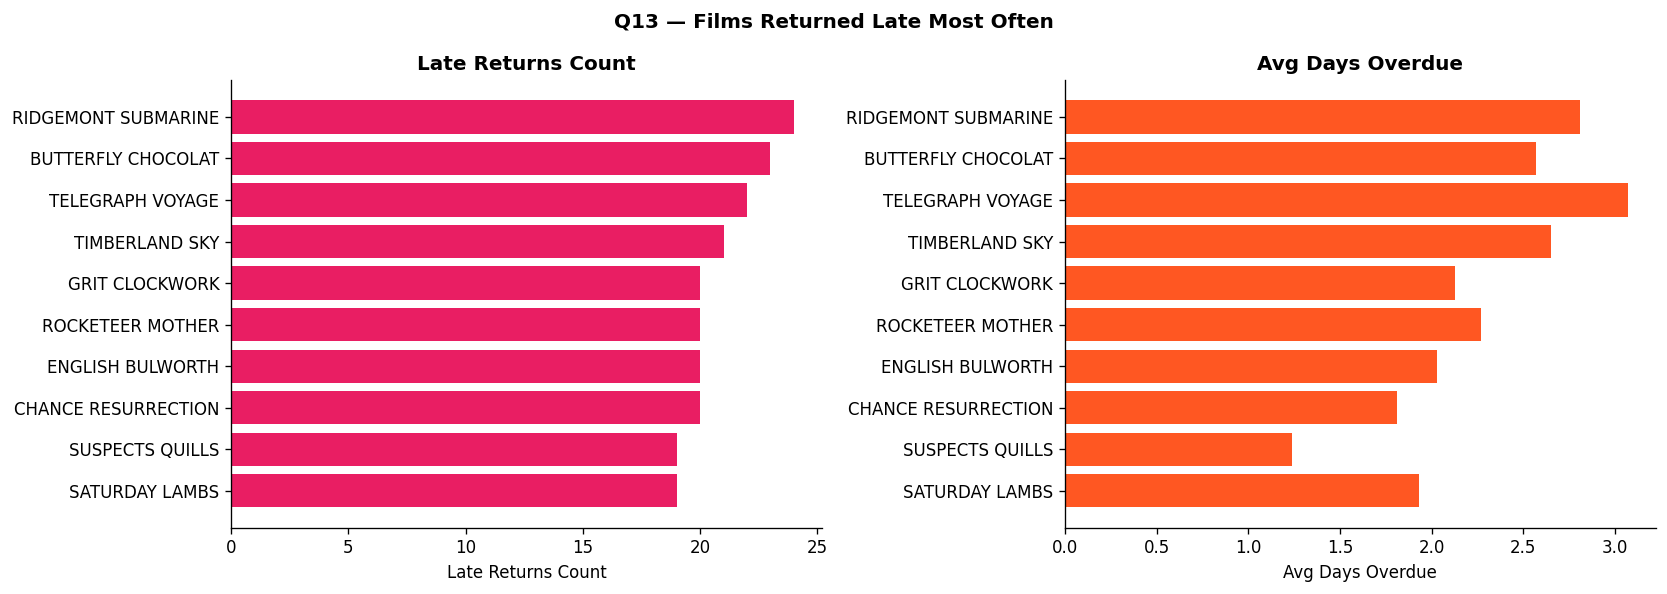

In [14]:
q13 = pd.read_sql('''
    SELECT f.title,
           c.name                           AS category,
           COUNT(r.rental_key)              AS total_rentals,
           SUM(CASE WHEN r.days_overdue > 0
                    THEN 1 ELSE 0 END)      AS late_returns,
           ROUND(AVG(r.days_overdue), 2)    AS avg_days_overdue
    FROM   fact_rental  r
    JOIN   dim_film     f ON r.film_key     = f.film_key
    JOIN   dim_category c ON r.category_key = c.category_key
    WHERE  r.is_returned = 1
    GROUP  BY f.film_key, f.title, c.name
    HAVING late_returns > 0
    ORDER  BY late_returns DESC
    LIMIT  10
''', dw)

print("Q13 — Top 10 Films with Most Late Returns")
print(q13.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.barh(q13['title'][::-1], q13['late_returns'][::-1], color='#E91E63')
ax1.set_xlabel('Late Returns Count')
ax1.set_title('Late Returns Count', fontweight='bold')

ax2.barh(q13['title'][::-1], q13['avg_days_overdue'][::-1], color='#FF5722')
ax2.set_xlabel('Avg Days Overdue')
ax2.set_title('Avg Days Overdue', fontweight='bold')

plt.suptitle('Q13 — Films Returned Late Most Often', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Q14 — How does store performance differ by location?

Q14 — Store Performance by Location
 store_id             location manager_name  total_rentals  total_revenue  avg_payment  unique_customers  avg_rental_days
        2 Woodridge, Australia Jon Stephens           8121       33726.77         4.15               599             4.51
        1   Lethbridge, Canada Mike Hillyer           7923       33679.79         4.25               599             4.54


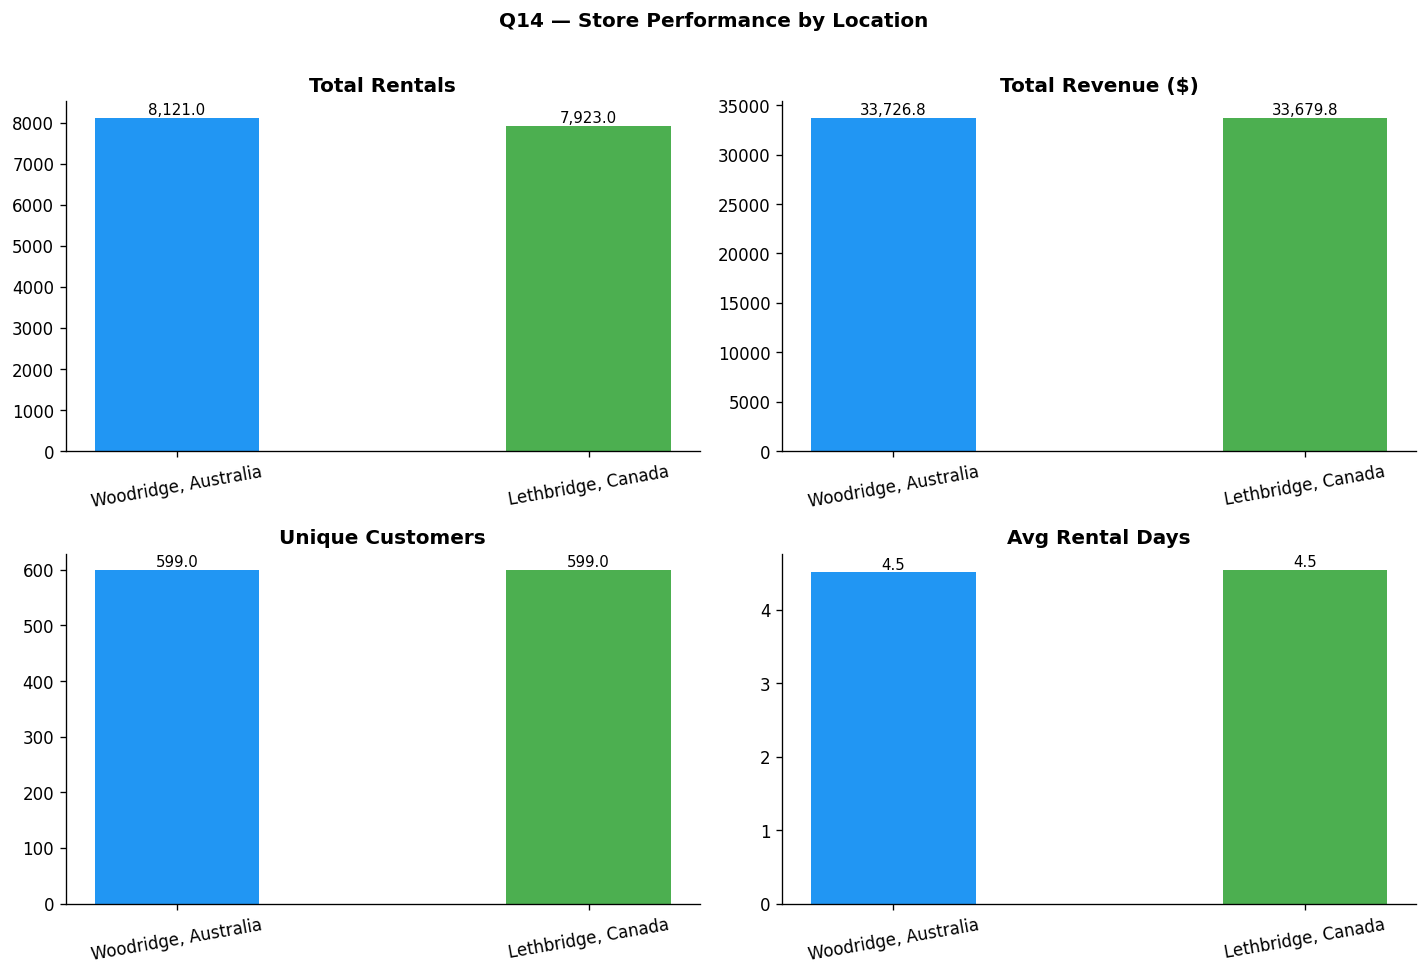

In [15]:
q14 = pd.read_sql('''
    SELECT s.store_id,
           CONCAT(s.city,', ',s.country)    AS location,
           s.manager_name,
           COUNT(r.rental_key)              AS total_rentals,
           ROUND(SUM(p.amount_paid),2)      AS total_revenue,
           ROUND(AVG(p.amount_paid),2)      AS avg_payment,
           COUNT(DISTINCT r.customer_key)   AS unique_customers,
           ROUND(AVG(r.rental_duration_days),2) AS avg_rental_days
    FROM   fact_rental  r
    JOIN   dim_store    s ON r.store_key  = s.store_key
    JOIN   fact_payment p ON r.rental_key = p.rental_key
    GROUP  BY s.store_key, s.store_id, s.city, s.country, s.manager_name
    ORDER  BY total_revenue DESC
''', dw)

print("Q14 — Store Performance by Location")
print(q14.to_string(index=False))

metrics = ['total_rentals','total_revenue','unique_customers','avg_rental_days']
labels  = ['Total Rentals','Total Revenue ($)','Unique Customers','Avg Rental Days']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, (metric, label) in enumerate(zip(metrics, labels)):
    bars = axes[i].bar(q14['location'], q14[metric],
                       color=['#2196F3','#4CAF50'], width=0.4)
    axes[i].set_title(label, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=10)
    for b in bars:
        axes[i].text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                     f'{b.get_height():,.1f}', ha='center', fontsize=9)
plt.suptitle('Q14 — Store Performance by Location', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


---
## Q15 — What are the most active customer locations?

Q15 — Top 15 Most Active Customer Locations (Cities)
                city              country  unique_customers  total_rentals  total_revenue
              London       United Kingdom                 2             48         180.52
              Aurora        United States                 2             50         198.50
    ´s-Hertogenbosch          Netherlands                 1             23          90.77
A Coruña (La Coruña)                Spain                 1             29         107.71
                Abha         Saudi Arabia                 1             24          96.76
           Abu Dhabi United Arab Emirates                 1             32         107.68
               Acuña               Mexico                 1             26         113.74
               Adana               Turkey                 1             26         112.74
         Addis Abeba             Ethiopia                 1             23          91.77
                Aden                Yemen      

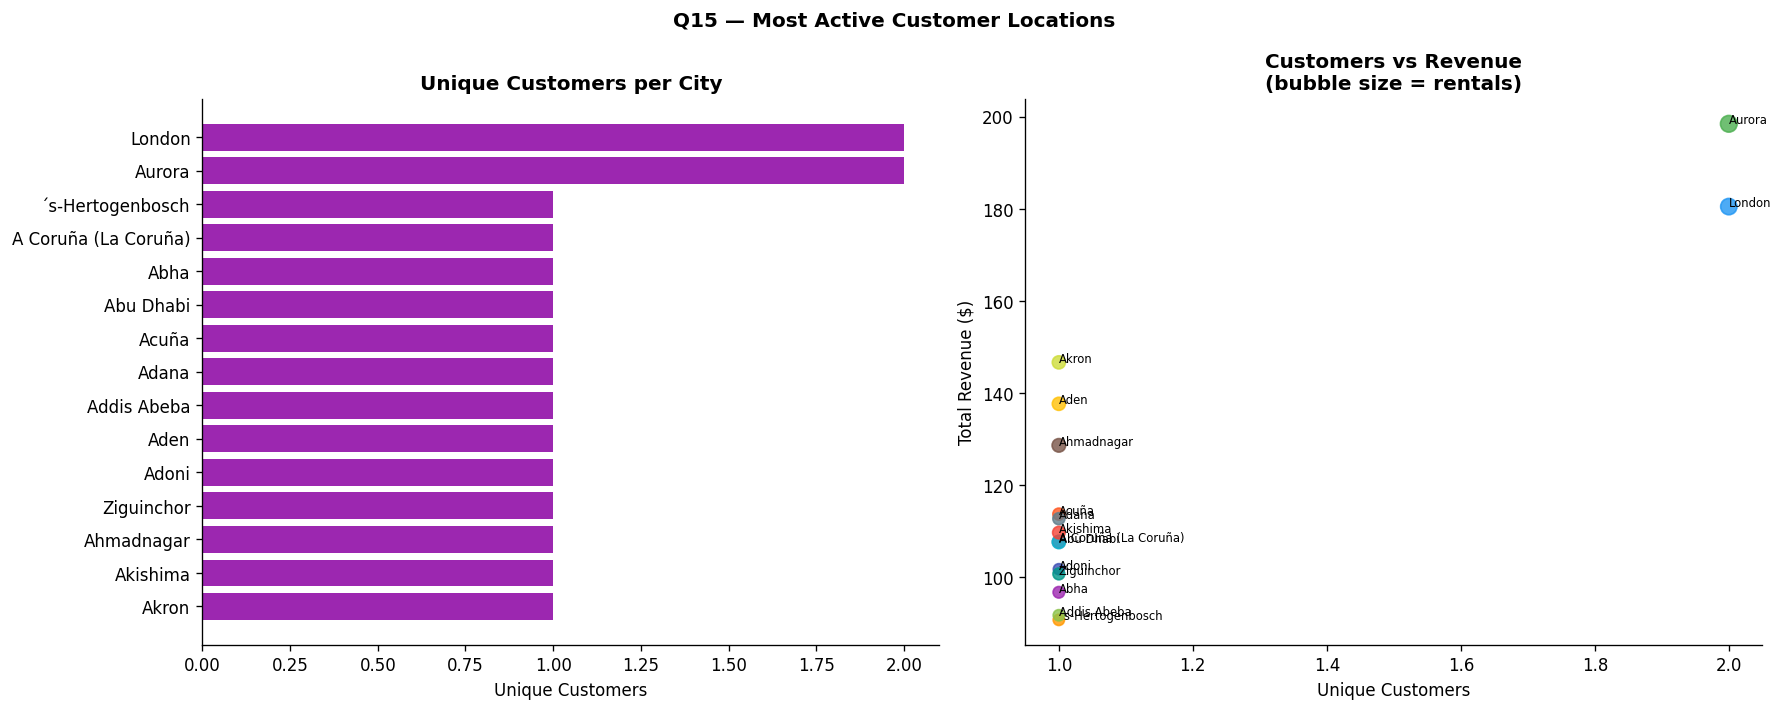

In [16]:
# top cities
q15ci = pd.read_sql('''
    SELECT c.city, c.country,
           COUNT(DISTINCT r.customer_key)  AS unique_customers,
           COUNT(r.rental_key)             AS total_rentals,
           ROUND(SUM(p.amount_paid),2)     AS total_revenue
    FROM   fact_rental  r
    JOIN   dim_customer c ON r.customer_key = c.customer_key
    JOIN   fact_payment p ON r.rental_key   = p.rental_key
    WHERE  c.is_current = 1
    GROUP  BY c.city, c.country
    ORDER  BY unique_customers DESC
    LIMIT  15
''', dw)

print("Q15 — Top 15 Most Active Customer Locations (Cities)")
print(q15ci.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# unique customers
axes[0].barh(q15ci['city'][::-1], q15ci['unique_customers'][::-1], color='#9C27B0')
axes[0].set_xlabel('Unique Customers')
axes[0].set_title('Unique Customers per City', fontweight='bold')

# scatter: customers vs revenue
axes[1].scatter(q15ci['unique_customers'], q15ci['total_revenue'],
                s=q15ci['total_rentals']*2, c=C[:len(q15ci)], alpha=0.8)
for _, row in q15ci.iterrows():
    axes[1].annotate(row['city'],
                     (row['unique_customers'], row['total_revenue']),
                     fontsize=7, ha='left')
axes[1].set_xlabel('Unique Customers')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_title('Customers vs Revenue\n(bubble size = rentals)', fontweight='bold')

plt.suptitle('Q15 — Most Active Customer Locations', fontweight='bold')
plt.tight_layout(); plt.show()


---
## ✅ Summary — All 15 Business Questions Answered

In [17]:
rows = [
    ('Q1',  'Most rented films',                        'fact_rental'),
    ('Q2',  'Highest revenue films',                    'fact_rental + fact_payment'),
    ('Q3',  'Most popular categories',                  'fact_rental'),
    ('Q4',  'Stores by number of rentals',              'fact_rental'),
    ('Q5',  'Stores by revenue',                        'fact_rental + fact_payment'),
    ('Q6',  'Customers by rental count',                'fact_rental'),
    ('Q7',  'Customers by revenue',                     'fact_rental + fact_payment'),
    ('Q8',  'Rental activity over time',                'fact_rental + dim_date'),
    ('Q9',  'Revenue by month / quarter / year',        'fact_payment + dim_date'),
    ('Q10', 'Staff rentals and payments performance',   'fact_rental + fact_payment'),
    ('Q11', 'Cities & countries by customer activity',  'fact_rental + dim_customer'),
    ('Q12', 'Avg rental duration by film / category',   'fact_rental'),
    ('Q13', 'Films returned late most often',           'fact_rental'),
    ('Q14', 'Store performance by location',            'fact_rental + fact_payment'),
    ('Q15', 'Most active customer locations',           'fact_rental + fact_payment'),
]
df = pd.DataFrame(rows, columns=['#','Business Question','Fact Table(s) Used'])
print("=" * 72)
print("        SAKILA DATA WAREHOUSE — ALL BUSINESS QUESTIONS COMPLETE")
print("=" * 72)
print(df.to_string(index=False))
print()
print("  Each question: result table + chart ✓")
print("  All queries use populated fact tables ✓")


        SAKILA DATA WAREHOUSE — ALL BUSINESS QUESTIONS COMPLETE
  #                       Business Question         Fact Table(s) Used
 Q1                       Most rented films                fact_rental
 Q2                   Highest revenue films fact_rental + fact_payment
 Q3                 Most popular categories                fact_rental
 Q4             Stores by number of rentals                fact_rental
 Q5                       Stores by revenue fact_rental + fact_payment
 Q6               Customers by rental count                fact_rental
 Q7                    Customers by revenue fact_rental + fact_payment
 Q8               Rental activity over time     fact_rental + dim_date
 Q9       Revenue by month / quarter / year    fact_payment + dim_date
Q10  Staff rentals and payments performance fact_rental + fact_payment
Q11 Cities & countries by customer activity fact_rental + dim_customer
Q12  Avg rental duration by film / category                fact_rental
Q13          